In [24]:
import sys
!{sys.executable} -m pip install matplotlib seaborn --break-system-packages

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
path = "/Users/sahana/Documents/CMPE_255/rag_project/Intelligent-E-Commerce-Search-with-Retrieval-Augmented-Generation/clean_data.csv"
combined_df = pd.read_csv(path)

# /Users/sahana/Documents/CMPE_255/rag_project/Intelligent-E-Commerce-Search-with-Retrieval-Augmented-Generation/clean_data.csv



In [26]:
#  Styling

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 150
})

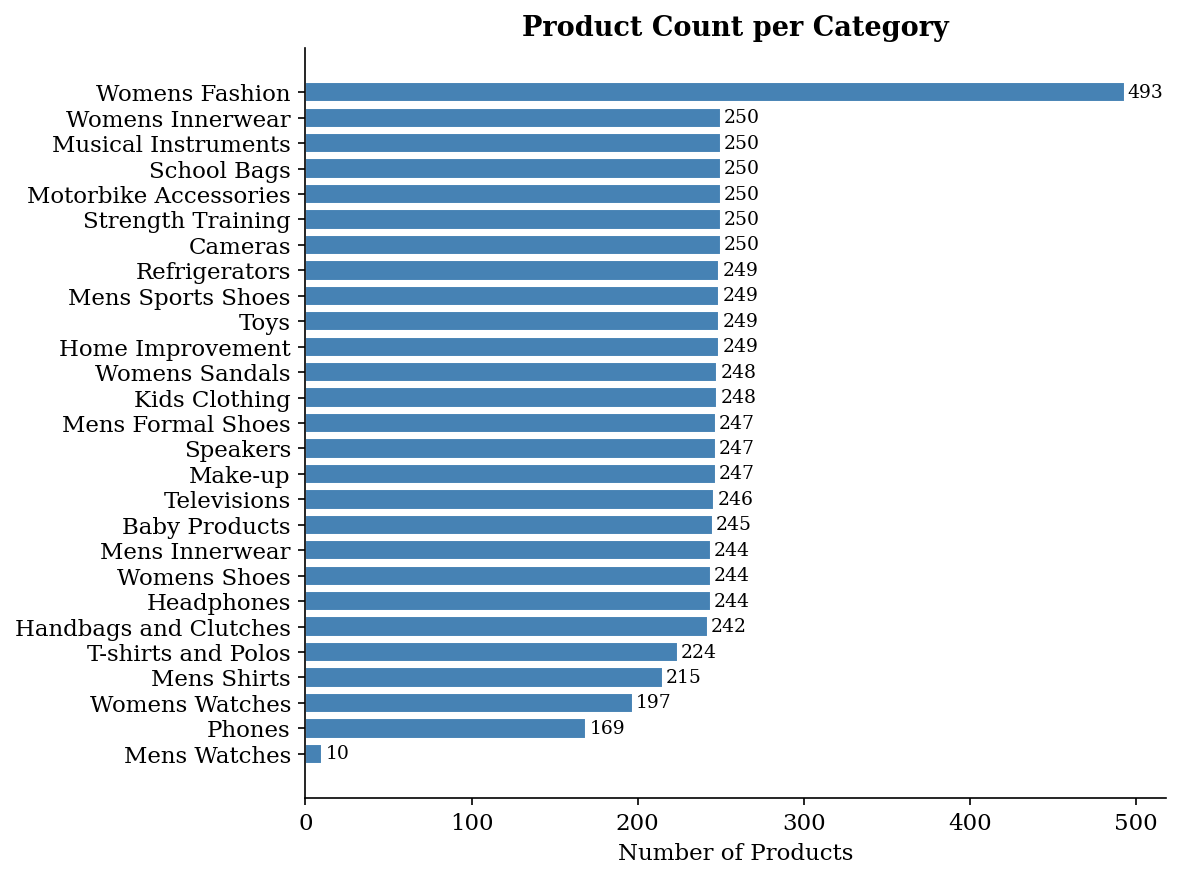

Saved: eda1_category_distribution.png


In [ ]:
# EDA 1: Product Count per Category
# Shows dataset diversity — the RAG system must handle broad variety across 28 categories

category_counts = combined_df['main_category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(category_counts.index, category_counts.values, color='steelblue', edgecolor='white')

# Annotate bar values
for bar, val in zip(bars, category_counts.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of Products')
ax.set_title('Product Count per Category')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('eda1_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: eda1_category_distribution.png")

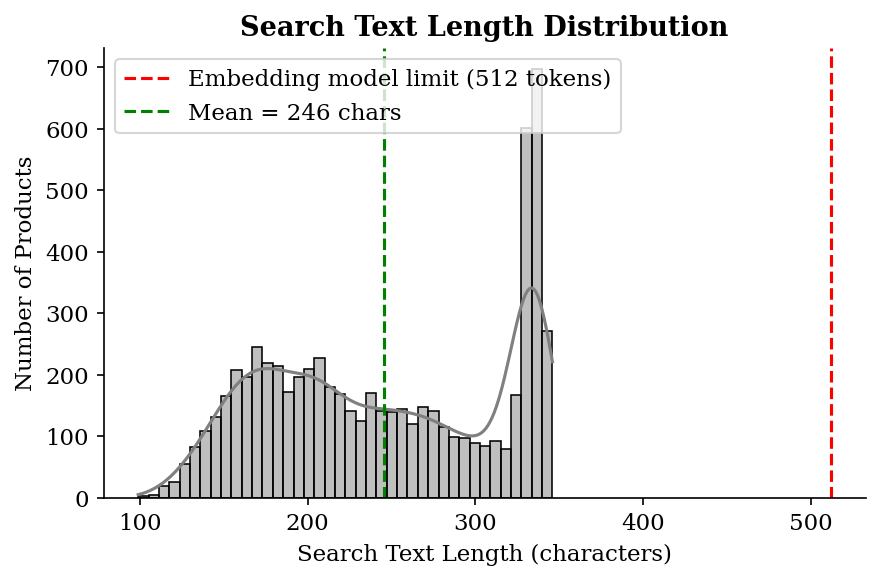

Saved: eda2_search_text_length.png


In [ ]:

# EDA 2: Search Text Length Distribution
# A key RAG design decision — no chunking needed
# because all documents fit within the 512-token embedding limit

combined_df['search_text_len'] = combined_df['search_text'].str.len()

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(combined_df['search_text_len'], bins=40, kde=True,
             color='grey', ax=ax)

ax.axvline(x=512, color='red', linestyle='--', linewidth=1.5,
           label='Embedding model limit (512 tokens)')
ax.axvline(x=combined_df['search_text_len'].mean(), color='green',
           linestyle='--', linewidth=1.5,
           label=f"Mean = {combined_df['search_text_len'].mean():.0f} chars")

ax.set_xlabel('Search Text Length (characters)')
ax.set_ylabel('Number of Products')
ax.set_title('Search Text Length Distribution')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('eda2_search_text_length.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: eda2_search_text_length.png")




In [29]:
import sys
!{sys.executable} -m pip install folium scikit-learn matplotlib mlxtend adjustText --break-system-packages

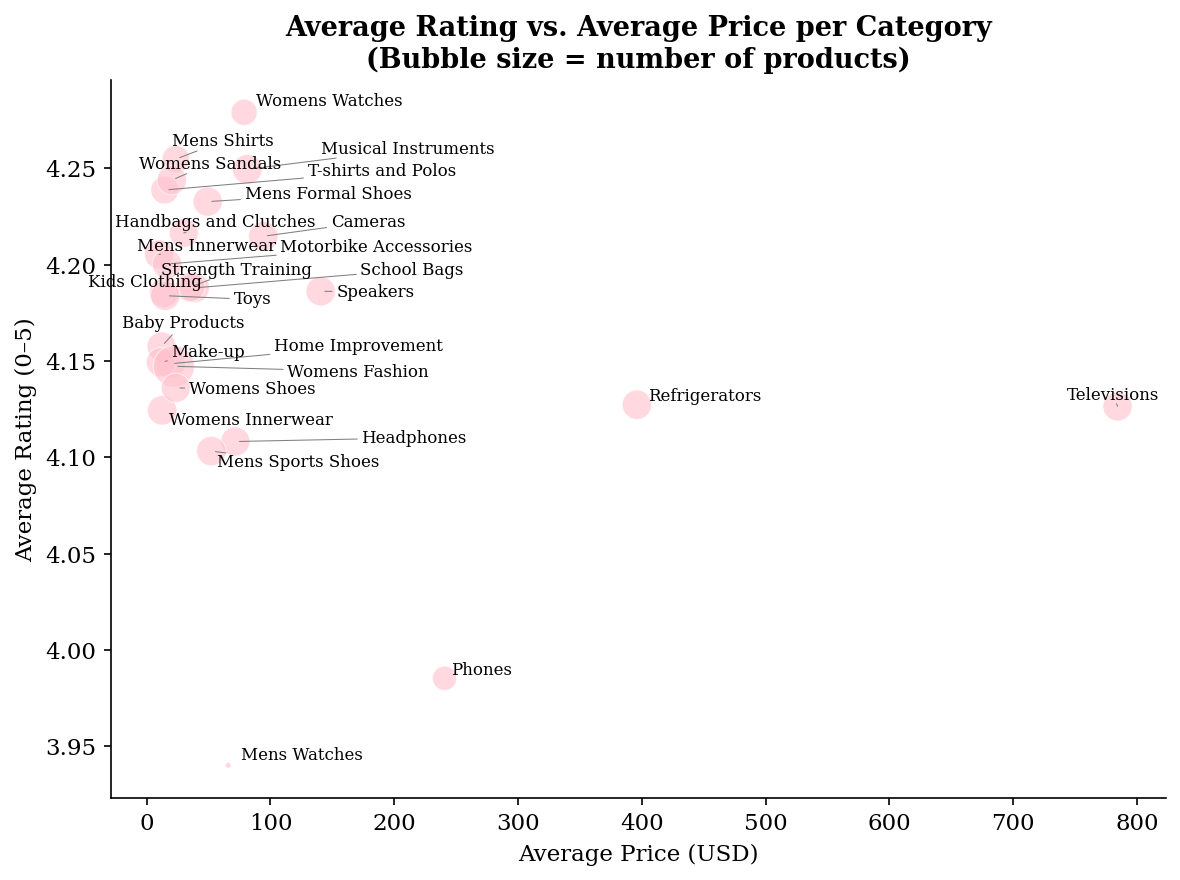

In [ ]:
# EDA 3: Average Rating vs Average Price per Category 
# Shows semantic richness of the catalog — categories differ in price
# and quality signal, meaning the retrieval system must rely on
# semantic meaning, not just price or rating filters

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    category_stats['avg_price'],
    category_stats['avg_rating'],
    s=category_stats['count'] * 0.8,
    alpha=0.6,
    color='pink',
    edgecolors='white',
    linewidths=0.5
)

# Smart label placement using adjustText library
from adjustText import adjust_text

texts = []
for _, row in category_stats.iterrows():
    texts.append(ax.text(
        row['avg_price'], row['avg_rating'],
        row['main_category'],
        fontsize=8
    ))

# Auto-adjusts labels to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

ax.set_xlabel('Average Price (USD)')
ax.set_ylabel('Average Rating (0–5)')
ax.set_title('Average Rating vs. Average Price per Category\n(Bubble size = number of products)')
sns.despine()
plt.tight_layout()
plt.savefig('eda3_rating_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()